In [22]:
# Utility functions: NMS (no contrib) and GT dilation
import numpy as np
import cv2

# def nms_edge(pred):
#     # Gaussian smooth then skeletonize via morphological method (no ximgproc)
#     pred_blur = cv2.GaussianBlur(pred, (3,3), 0)
#     pred_uint8 = (np.clip(pred_blur, 0.0, 1.0) * 255).astype(np.uint8)
#     _, bw = cv2.threshold(pred_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#     bw = (bw // 255).astype(np.uint8)
#     skeleton = np.zeros_like(bw, dtype=np.uint8)
#     element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
#     img = bw.copy()
#     while True:
#         eroded = cv2.erode(img, element)
#         temp = cv2.dilate(eroded, element)
#         temp = cv2.subtract(img, temp)
#         skeleton = cv2.bitwise_or(skeleton, temp)
#         img = eroded
#         if cv2.countNonZero(img) == 0:
#             break
#     return skeleton.astype(np.float32)
def nms_edge(pred):
    pred_blur = cv2.GaussianBlur(pred, (3,3), 0)
    pred_uint8 = (np.clip(pred_blur, 0.0, 1.0) * 255).astype(np.uint8)

    # Canny-based thinning surrogate
    edges = cv2.Canny(pred_uint8, 50, 150)

    return edges.astype(np.float32) / 255.0

def dilate_gt(gt, r=1):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    return cv2.dilate(gt, kernel)



| Pathway | What it does | Implementation |
|---------|--------------|----------------|
| **X** | Local contrast (center-surround) | `3×3 Conv` - `1×1 Conv` |
| **Y** | Large RF contrast | `5×5 Dilated Conv` - `1×1 Conv` |
| **W** | Directional | `1×3 Conv` (horizontal) + `3×1 Conv` (vertical) |

**W pathway is NOT Gabor filters** - it's separable directional convolutions.

**Gabor filters** are specifically oriented edge detectors with sinusoidal patterns at different angles (0°, 45°, 90°, 135°, etc.). They're biologically inspired by V1 cortex cells.



In [23]:
# Cell 1: Imports and Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from sklearn.metrics import precision_recall_curve, average_precision_score
import os
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce GTX 1070
Memory: 8.6 GB


In [24]:
# os.listdir("/kaggle/input/hed-bsds-v2/processed_HED_v2")


In [25]:
# os.listdir("/kaggle/input/12epoch/pytorch/default/1")
# 

In [26]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("Total VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


CUDA available: True
GPU name: NVIDIA GeForce GTX 1070
Total VRAM (GB): 8.0


In [27]:
import os

# BASE = "/kaggle/input/hed-bsds-v2/processed_HED_v2"
BASE = "./datasets/HED_Small"

print("ROOT:", os.listdir(BASE))
print("TRAIN:", os.listdir(BASE + "/train"))
print("TRAIN/IMAGES:", os.listdir(BASE + "/train/images")[:10])
print("TRAIN/EDGES:", os.listdir(BASE + "/train/edges")[:10])


ROOT: ['test', 'train', 'val']
TRAIN: ['edges', 'images']
TRAIN/IMAGES: ['hedbsds_train_000219.png', 'hedbsds_train_000829.png', 'hedbsds_train_001042.png', 'hedbsds_train_001490.png', 'hedbsds_train_001587.png', 'hedbsds_train_002042.png', 'hedbsds_train_002059.png', 'hedbsds_train_002888.png', 'hedbsds_train_003152.png', 'hedbsds_train_003371.png']
TRAIN/EDGES: ['hedbsds_train_000219.png', 'hedbsds_train_000829.png', 'hedbsds_train_001042.png', 'hedbsds_train_001490.png', 'hedbsds_train_001587.png', 'hedbsds_train_002042.png', 'hedbsds_train_002059.png', 'hedbsds_train_002888.png', 'hedbsds_train_003152.png', 'hedbsds_train_003371.png']


In [28]:
import cv2
import os
import numpy as np
from pathlib import Path
from tqdm import tqdm

def verify_edges(root_dir, split="train"):
    """Verify dataset integrity for a given split"""
    root_dir = Path(root_dir)
    img_dir = root_dir / split / "images"
    edge_dir = root_dir / split / "edges"

    # Check if split directories exist
    if not img_dir.exists() or not edge_dir.exists():
        print(f"⚠ Split '{split}' not found in {root_dir}")
        return

    image_files = sorted(list(img_dir.glob("*.png")))
    if len(image_files) == 0:
        print(f"⚠ No PNG files in {img_dir}")
        return

    missing_edges = []
    unreadable_edges = []
    empty_edges = []
    size_mismatch = []

    print(f"\nVerifying split: {split}")
    print("=" * 60)

    for img_path in tqdm(image_files, desc=f"Checking {split}", unit="img"):
        edge_path = edge_dir / img_path.name

        # 1. Check if edge file exists
        if not edge_path.exists():
            missing_edges.append(img_path.name)
            continue

        # 2. Try loading edge
        edge = cv2.imread(str(edge_path), cv2.IMREAD_GRAYSCALE)
        if edge is None:
            unreadable_edges.append(img_path.name)
            continue

        # 3. Check if edge is empty (all zeros)
        if np.sum(edge) == 0:
            empty_edges.append(img_path.name)

        # 4. Check size match
        img = cv2.imread(str(img_path))
        if img is None or edge.shape != img.shape[:2]:
            size_mismatch.append(img_path.name)

    # ===== REPORT =====
    print(f"\nVerification Report for split: {split}")
    print("=" * 60)
    print(f"Total images checked: {len(image_files)}")
    print(f"Missing edge files: {len(missing_edges)}")
    print(f"Unreadable edge files: {len(unreadable_edges)}")
    print(f"Empty edge maps: {len(empty_edges)}")
    print(f"Size mismatches: {len(size_mismatch)}")

    if missing_edges:
        print("\nMissing edge files (first 10):")
        print(missing_edges[:10])

    if unreadable_edges:
        print("\nUnreadable edge files (first 10):")
        print(unreadable_edges[:10])

    if empty_edges:
        print("\nEmpty edge maps (first 10):")
        print(empty_edges[:10])

    if size_mismatch:
        print("\nSize mismatches (first 10):")
        print(size_mismatch[:10])

    if not (missing_edges or unreadable_edges or empty_edges or size_mismatch):
        print("\n✓ All images have valid, non-empty, correctly-sized edge maps.")

# =========================
# Verify all available splits
# =========================
print(f"Using dataset root: {DATA_ROOT}")
print("=" * 60)

for split in ["train", "val", "test"]:
    verify_edges(DATA_ROOT, split)

Using dataset root: ./datasets/HED_Small

Verifying split: train


Checking train: 100%|██████████| 35/35 [00:00<00:00, 296.94img/s]



Verification Report for split: train
Total images checked: 35
Missing edge files: 0
Unreadable edge files: 0
Empty edge maps: 0
Size mismatches: 0

✓ All images have valid, non-empty, correctly-sized edge maps.

Verifying split: val


Checking val: 100%|██████████| 8/8 [00:00<00:00, 295.07img/s]



Verification Report for split: val
Total images checked: 8
Missing edge files: 0
Unreadable edge files: 0
Empty edge maps: 0
Size mismatches: 0

✓ All images have valid, non-empty, correctly-sized edge maps.

Verifying split: test


Checking test: 100%|██████████| 7/7 [00:00<00:00, 304.33img/s]


Verification Report for split: test
Total images checked: 7
Missing edge files: 0
Unreadable edge files: 0
Empty edge maps: 0
Size mismatches: 0

✓ All images have valid, non-empty, correctly-sized edge maps.


In [29]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import cv2
import torch
import numpy as np
import os

# Cell 2: Environment-aware Dataset Loader
class ProcessedDataset(Dataset):
    """Load processed PNG images and edge maps with ImageNet normalization"""

    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir)
        self.split = split
        self.img_dir = self.root_dir / split / 'images'
        self.edge_dir = self.root_dir / split / 'edges'
        
        # Verify paths exist
        if not self.img_dir.exists():
            raise FileNotFoundError(f"Image directory not found: {self.img_dir}")
        if not self.edge_dir.exists():
            raise FileNotFoundError(f"Edge directory not found: {self.edge_dir}")
        
        self.samples = sorted(list(self.img_dir.glob('*.png')))
        if len(self.samples) == 0:
            raise ValueError(f"No PNG files found in {self.img_dir}")
        
        # ImageNet normalization (standard for edge detection models)
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        edge_path = self.edge_dir / img_path.name

        # Load image
        img = cv2.imread(str(img_path))
        if img is None:
            raise IOError(f"Failed to load image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0

        # Load edge map
        edge = cv2.imread(str(edge_path), cv2.IMREAD_GRAYSCALE)
        if edge is None:
            raise IOError(f"Failed to load edge map: {edge_path}")
        edge = edge.astype(np.float32) / 255.0

        # To tensors
        img = torch.from_numpy(img).permute(2, 0, 1)
        # Apply ImageNet normalization
        img = (img - self.mean) / self.std
        edge = torch.from_numpy(edge).unsqueeze(0)

        return {'images': img, 'labels': edge, 'filename': img_path.stem}


# ============================================================
# Environment Detection: Local / Kaggle / HPC
# ============================================================
def detect_environment():
    """Auto-detect execution environment and choose dataset path + num_workers"""
    
    # 1. Check if Kaggle
    if os.path.exists("/kaggle/input"):
        env = "kaggle"
        paths = [
            "/kaggle/input/hed-bsds-v2/HED_Small",
            "/kaggle/input/hed-bsds-v2/processed_HED_v2",
        ]
        num_workers = 2  # Kaggle allows multi-process I/O
    
    # 2. Check if HPC (Slurm environment variables)
    elif "SLURM_JOB_ID" in os.environ or "PBS_JOBID" in os.environ:
        env = "hpc"
        paths = [
            "./datasets/HED_Small",
            "/scratch/datasets/HED_Small",
            "/data/HED_Small",
        ]
        num_workers = min(4, os.cpu_count() - 1) if os.cpu_count() else 2
    
    # 3. Default: Local
    else:
        env = "local"
        paths = ["./datasets/HED_Small"]
        num_workers = 0  # Windows/Mac often have issues with multiprocessing
    
    # Find first existing path
    data_root = None
    for p in paths:
        if os.path.exists(p):
            data_root = p
            break
    
    if data_root is None:
        print(f"⚠ WARNING: No dataset found in {env.upper()} environment.")
        print(f"Tried paths: {paths}")
        print("Using default path (may fail if dataset not available):")
        data_root = paths[0]
    
    return env, data_root, num_workers

# Auto-detect
environment, DATA_ROOT, NUM_WORKERS = detect_environment()
print(f"Environment: {environment.upper()}")
print(f"Dataset root: {DATA_ROOT}")
print(f"num_workers: {NUM_WORKERS}")
print("=" * 60)

# ============================================================
# Load Datasets
# ============================================================
BATCH_SIZE = 4

try:
    train_dataset = ProcessedDataset(DATA_ROOT, split='train')
    val_dataset   = ProcessedDataset(DATA_ROOT, split='val') if os.path.exists(f"{DATA_ROOT}/val") else ProcessedDataset(DATA_ROOT, split='test')
    test_dataset  = ProcessedDataset(DATA_ROOT, split='test')
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    
    print(f"✓ Train: {len(train_dataset)} samples")
    print(f"✓ Val:   {len(val_dataset)} samples")
    print(f"✓ Test:  {len(test_dataset)} samples")
    
    # Verify sample
    sample = train_dataset[0]
    print(f"✓ Image shape: {sample['images'].shape}")
    print(f"✓ Edge shape:  {sample['labels'].shape}")
    print("=" * 60)
    
except Exception as e:
    print(f"✗ Dataset loading failed: {e}")
    print("Make sure the dataset path is correct and accessible.")

Environment: LOCAL
Dataset root: ./datasets/HED_Small
num_workers: 0
✓ Train: 35 samples
✓ Val:   8 samples
✓ Test:  7 samples
✓ Image shape: torch.Size([3, 512, 512])
✓ Edge shape:  torch.Size([1, 512, 512])


In [30]:
# Cell: Original-aligned XYW-Net model (encoder + RCF-style decoder) with ELC toggle
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np

# --- Decoder mode toggle ---
# Use 'rcf' for the baseline decoder (released code default), or 'elc' to enable the Edge Localization Convolution path.
DECODE_MODE = 'rcf'  # options: 'rcf' | 'elc'

# --- PDC (Pixel Difference Convolution) minimal subset ---
def createPDCFunc(PDC_type):
    assert PDC_type in ['cv', '2sd']
    if PDC_type == 'cv':
        return F.conv2d
    if PDC_type == '2sd':
        def func(x, weights, bias=None, stride=1, padding=0, dilation=1, groups=1):
            assert weights.size(2) == 3 and weights.size(3) == 3
            shape = weights.shape
            weights = weights.view(shape[0], shape[1], -1)
            buffer = weights.clone()
            buffer[:, :, [0, 1, 2, 3, 5, 6, 7, 8]] = buffer[:, :, [0, 1, 2, 3, 5, 6, 7, 8]] + \
                                                     buffer[:, :, [2, 7, 8, 5, 3, 0, 1, 6]] - \
                                                     2 * buffer[:, :, [1, 4, 5, 4, 4, 3, 4, 7]]
            buffer[:, :, [4]] = 0
            weights_conv = buffer.view(shape)
            return F.conv2d(x, weights_conv, bias, stride=stride, padding=padding, dilation=dilation, groups=groups)
        return func
    return F.conv2d

class Conv2d(nn.Module):
    def __init__(self, pdc_func, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=False):
        super().__init__()
        if in_channels % groups != 0:
            raise ValueError('in_channels must be divisible by groups')
        if out_channels % groups != 0:
            raise ValueError('out_channels must be divisible by groups')
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        self.groups = groups
        self.weight = nn.Parameter(torch.Tensor(out_channels, in_channels // groups, kernel_size, kernel_size))
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()
        self.pdc_func = createPDCFunc(pdc_func)

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return self.pdc_func(x, self.weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

# --- XYW components ---
class Xc1x1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.Xcenter = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.Xcenter_relu = nn.ReLU(inplace=True)
        self.Xsurround = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, groups=in_channels)
        self.conv1_1 = nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.Xsurround_relu = nn.ReLU(inplace=True)
    def forward(self, x):
        xcenter = self.Xcenter_relu(self.Xcenter(x))
        xsurround = self.Xsurround_relu(self.Xsurround(x))
        xsurround = self.conv1_1(xsurround)
        return xsurround - xcenter

class Yc1x1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.Ycenter = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.Ycenter_relu = nn.ReLU(inplace=True)
        self.Ysurround = nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=4, dilation=2, groups=in_channels)
        self.conv1_1 = nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.Ysurround_relu = nn.ReLU(inplace=True)
    def forward(self, x):
        ycenter = self.Ycenter_relu(self.Ycenter(x))
        ysurround = self.Ysurround_relu(self.Ysurround(x))
        ysurround = self.conv1_1(ysurround)
        return ysurround - ycenter

class W(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.h = nn.Conv2d(inchannel, inchannel, kernel_size=(1, 3), padding=(0, 1), groups=inchannel)
        self.v = nn.Conv2d(inchannel, inchannel, kernel_size=(3, 1), padding=(1, 0), groups=inchannel)
        self.convh_1 = nn.Conv2d(in_channels=inchannel, out_channels=inchannel, kernel_size=1, padding=0, bias=False)
        self.convv_1 = nn.Conv2d(in_channels=inchannel, out_channels=outchannel, kernel_size=1, padding=0, bias=False)
        self.relu = nn.ReLU()
    def forward(self, x):
        h = self.relu(self.h(x)); h = self.convh_1(h)
        v = self.relu(self.v(h)); v = self.convv_1(v)
        return v

class XYW_S(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.y_c = Yc1x1(inchannel, outchannel)
        self.x_c = Xc1x1(inchannel, outchannel)
        self.w = W(inchannel, outchannel)
    def forward(self, x):
        return self.x_c(x), self.y_c(x), self.w(x)

class XYW(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.y_c = Yc1x1(inchannel, outchannel)
        self.x_c = Xc1x1(inchannel, outchannel)
        self.w = W(inchannel, outchannel)
    def forward(self, xc, yc, w):
        return self.x_c(xc), self.y_c(yc), self.w(w)

class XYW_E(nn.Module):
    def __init__(self, inchannel, outchannel):
        super().__init__()
        self.y_c = Yc1x1(inchannel, outchannel)
        self.x_c = Xc1x1(inchannel, outchannel)
        self.w = W(inchannel, outchannel)
    def forward(self, xc, yc, w):
        return self.x_c(xc) + self.y_c(yc) + self.w(w)

# --- Encoder stages ---
class s1(nn.Module):
    def __init__(self, channel=30):
        super().__init__()
        self.conv1 = nn.Conv2d(3, channel, kernel_size=7, padding=6, dilation=2)
        self.xyw1_1 = XYW_S(channel, channel)
        self.xyw1_2 = XYW(channel, channel)
        self.xyw1_3 = XYW_E(channel, channel)
        self.relu = nn.ReLU()
    def forward(self, x):
        temp = self.relu(self.conv1(x))
        xc, yc, w = self.xyw1_1(temp)
        xc, yc, w = self.xyw1_2(xc, yc, w)
        xyw1_3 = self.xyw1_3(xc, yc, w)
        return xyw1_3 + temp

class s2(nn.Module):
    def __init__(self, channel=60):
        super().__init__()
        self.xyw2_1 = XYW_S(channel//2, channel)
        self.xyw2_2 = XYW(channel, channel)
        self.xyw2_3 = XYW_E(channel, channel)
        self.shortcut = nn.Conv2d(in_channels=channel//2, out_channels=channel, kernel_size=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x):
        x = self.pool(x)
        xc, yc, w = self.xyw2_1(x)
        xc, yc, w = self.xyw2_2(xc, yc, w)
        xyw2_3 = self.xyw2_3(xc, yc, w)
        shortcut = self.shortcut(x)
        return xyw2_3 + shortcut

class s3(nn.Module):
    def __init__(self, channel=120):
        super().__init__()
        self.xyw3_1 = XYW_S(channel//2, channel)
        self.xyw3_2 = XYW(channel, channel)
        self.xyw3_3 = XYW_E(channel, channel)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.shortcut = nn.Conv2d(in_channels=channel // 2, out_channels=channel, kernel_size=1, padding=0)
    def forward(self, x):
        x = self.pool(x)
        shortcut = self.shortcut(x)
        xc, yc, w = self.xyw3_1(x)
        xc, yc, w = self.xyw3_2(xc, yc, w)
        xyw3_3 = self.xyw3_3(xc, yc, w)
        return xyw3_3 + shortcut

class s4(nn.Module):
    def __init__(self, channel=120):
        super().__init__()
        self.xyw4_1 = XYW_S(channel, channel)
        self.xyw4_2 = XYW(channel, channel)
        self.xyw4_3 = XYW_E(channel, channel)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.shortcut = nn.Conv2d(in_channels=channel , out_channels=channel, kernel_size=1, padding=0)
    def forward(self, x):
        x = self.pool(x)
        shortcut = self.shortcut(x)
        xc, yc, w = self.xyw4_1(x)
        xc, yc, w = self.xyw4_2(xc, yc, w)
        xyw4_3 = self.xyw4_3(xc, yc, w)
        return xyw4_3 + shortcut

class encode(nn.Module):
    def __init__(self):
        super().__init__()
        self.s1_ = s1()
        self.s2_ = s2()
        self.s3_ = s3()
        self.s4_ = s4()
    def forward(self, x):
        s1o = self.s1_(x)
        s2o = self.s2_(s1o)
        s3o = self.s3_(s2o)
        s4o = self.s4_(s3o)
        return s1o, s2o, s3o, s4o

# --- Bilinear upsample weights ---
def upsample_filt(size):
    factor = (size + 1) // 2
    center = factor - 1 if size % 2 == 1 else factor - 0.5
    og = np.ogrid[:size, :size]
    return (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)

def bilinear_upsample_weights(factor, number_of_classes):
    filter_size = 2 * factor - factor % 2
    weights = np.zeros((number_of_classes, number_of_classes, filter_size, filter_size), dtype=np.float32)
    upsample_kernel = upsample_filt(filter_size)
    for i in range(number_of_classes):
        weights[i, i, :, :] = upsample_kernel
    return torch.Tensor(weights)

# --- Adaptive conv (gated) ---
class adap_conv(nn.Module):
    def __init__(self, in_channels, out_channels, kz=3, pd=1):
        super().__init__()
        self.conv = nn.Sequential(
            Conv2d('2sd', in_channels, out_channels, kernel_size=kz, padding=pd),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.weight = nn.Parameter(torch.Tensor([0.]))
    def forward(self, x):
        return self.conv(x) * self.weight.sigmoid()

class Refine_block2_1(nn.Module):
    def __init__(self, in_channel, out_channel, factor, require_grad=False):
        super().__init__()
        self.pre_conv1 = adap_conv(in_channel[0], out_channel, kz=3, pd=1)
        self.pre_conv2 = adap_conv(in_channel[1], out_channel, kz=3, pd=1)
        self.factor = factor
        self.deconv_weight = nn.Parameter(bilinear_upsample_weights(factor, out_channel), requires_grad=require_grad)
    def forward(self, x1, x2):
        x1 = self.pre_conv1(x1)
        x2 = self.pre_conv2(x2)
        x2 = F.conv_transpose2d(x2, self.deconv_weight, stride=self.factor, padding=int(self.factor/2),
                                output_padding=(x1.size(2) - x2.size(2)*self.factor, x1.size(3) - x2.size(3)*self.factor))
        return x1 + x2

# --- RCF-style decoder returning probability map ---
class decode_rcf(nn.Module):
    def __init__(self):
        super().__init__()
        self.f43 = Refine_block2_1(in_channel=(120, 120), out_channel=60, factor=2)
        self.f32 = Refine_block2_1(in_channel=(60, 60), out_channel=30, factor=2)
        self.f21 = Refine_block2_1(in_channel=(30, 30), out_channel=24, factor=2)
        self.f = nn.Conv2d(24, 1, kernel_size=1, padding=0)
    def forward(self, x):
        s3 = self.f43(x[2], x[3])
        s2 = self.f32(x[1], s3)
        s1 = self.f21(x[0], s2)
        out = self.f(s1)
        return out.sigmoid()

# --- ELC Block (Edge Localization Convolution) producing logits ---
class ELCBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = Conv2d('2sd', in_channels, in_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv_out = nn.Conv2d(in_channels, 1, kernel_size=1)
    def forward(self, x):
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.relu(x)
        return self.conv_out(x)  # logits

# --- ELC-style decoder: same refine pyramid, then ELCBlock + sigmoid ---
class decode_elc(nn.Module):
    def __init__(self):
        super().__init__()
        self.f43 = Refine_block2_1(in_channel=(120, 120), out_channel=60, factor=2)
        self.f32 = Refine_block2_1(in_channel=(60, 60), out_channel=30, factor=2)
        self.f21 = Refine_block2_1(in_channel=(30, 30), out_channel=24, factor=2)
        self.elc = ELCBlock(in_channels=24)
    def forward(self, x):
        s3 = self.f43(x[2], x[3])
        s2 = self.f32(x[1], s3)
        s1 = self.f21(x[0], s2)
        logits = self.elc(s1)
        return logits.sigmoid()

# --- Full XYW-Net ---
class XYWNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encode = encode()
        self.decode = decode_rcf() if DECODE_MODE == 'rcf' else decode_elc()
    def forward(self, x):
        end_points = self.encode(x)
        return self.decode(end_points)
    def forward_with_stages(self, x):
        s1o, s2o, s3o, s4o = self.encode(x)
        final = self.decode((s1o, s2o, s3o, s4o))
        return final, (s1o, s2o, s3o, s4o)


In [31]:
# ============================================================
#  ELC BLOCK (Edge Localization Convolution) - OUTPUTS LOGITS
# ============================================================
class ELCBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.pdc = Conv2d('2sd', ch, ch, 3, padding=1)
        self.norm = nn.InstanceNorm2d(ch)
        self.relu = nn.ReLU(inplace=True)
        self.out = nn.Conv2d(ch, 1, 1)

    def forward(self, x):
        x = self.pdc(x)
        x = self.norm(x)
        x = self.relu(x)
        # Output logits (NO sigmoid here - applied only at eval)
        return self.out(x)


In [33]:
# ============================================
# LOSS + METRICS (Aligned with original repo)
# ============================================

import numpy as np
import cv2
from sklearn.metrics import average_precision_score

# ------------------------------------------------
# 1. LOSS FUNCTION (Cross_Entropy on probabilities)
#    - optional dice component to mirror original utils.py
# ------------------------------------------------
DICE_COEFF = 0.0  # set to 0.1 to enable a small dice term like original

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.eps = 1e-6

    def _cross_entropy_with_weight(self, pred, labels):
        # pred, labels: (1, H, W) or (H, W) after slicing
        p = pred.view(-1).clamp(self.eps, 1.0 - self.eps)
        y = labels.view(-1)
        pos = y > 0
        neg = y == 0
        p_pos = p[pos]
        p_neg = p[neg]
        w_pos = y[pos]  # annotation strength (1 for binary)
        loss = 0.0
        if p_pos.numel() > 0:
            loss = loss + (-p_pos.log() * w_pos).mean()
        if p_neg.numel() > 0:
            loss = loss + (-(1.0 - p_neg).log()).mean()
        return loss

    def _dice_loss(self, pred, labels):
        p = pred.view(-1)
        y = labels.view(-1)
        # dice on probabilities
        num = (p * y).sum() * 2 + self.eps
        den = p.sum() + y.sum() + self.eps
        return (num / den).pow(-1)

    def forward(self, pred, labels):
        # Average per-image (batch-wise)
        B = pred.shape[0]
        total_ce = 0.0
        total_dice = 0.0
        for i in range(B):
            total_ce   = total_ce   + self._cross_entropy_with_weight(pred[i, 0], labels[i, 0])
            total_dice = total_dice + self._dice_loss(pred[i, 0], labels[i, 0])
        ce = total_ce / max(B, 1)
        dc = total_dice / max(B, 1)
        return ce + DICE_COEFF * dc

# ------------------------------------------------
# 2. NMS/thinning for predictions ONLY
#    Prefer ximgproc.thinning when available, fallback to Canny
# ------------------------------------------------
def nms_edge(pred):
    pred_blur = cv2.GaussianBlur(pred, (3,3), 0)
    pred_uint8 = (np.clip(pred_blur, 0, 1) * 255).astype(np.uint8)
    try:
        if hasattr(cv2, 'ximgproc') and hasattr(cv2.ximgproc, 'thinning'):
            edges = cv2.ximgproc.thinning(pred_uint8, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
        else:
            raise AttributeError
    except Exception:
        edges = cv2.Canny(pred_uint8, 50, 150)
    return edges.astype(np.float32) / 255.0

# ------------------------------------------------
# 3. GT TOLERANCE (matching only, GT unchanged)
# ------------------------------------------------
def dilate_gt(gt, r=1):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    return cv2.dilate(gt, kernel)

# ------------------------------------------------
# 4. METRICS: ODS / OIS / AP
# ------------------------------------------------
def compute_ods_ois_ap(preds, labels, thresholds=30):
    """
    Computes:
    - ODS: best F1 score using one threshold globally
    - OIS: average of best F1 per image
    - AP: average precision from score curve
    """

    threshs = np.linspace(0.05, 0.95, thresholds)

    all_preds = []
    all_labels = []
    ois_f1_scores = []

    # Per-image evaluation (for OIS)
    for pred, label in zip(preds, labels):
        label_binary = (label > 0.5).astype(np.float32)
        label_tol = dilate_gt(label_binary, r=1).flatten()
        pred_smooth = cv2.GaussianBlur(pred, (3,3), 0).flatten()
        all_preds.append(pred_smooth)
        all_labels.append(label_tol)

        best_f1 = 0.0
        for t in threshs:
            pred_bin = (pred_smooth >= t).astype(np.float32)
            tp = np.sum(pred_bin * label_tol)
            fp = np.sum(pred_bin * (1 - label_tol))
            fn = np.sum((1 - pred_bin) * label_tol)
            precision = tp / (tp + fp + 1e-8)
            recall    = tp / (tp + fn + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            best_f1 = max(best_f1, f1)
        ois_f1_scores.append(best_f1)

    # Flatten for ODS and AP
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Global threshold sweep (ODS)
    best_ods = 0.0
    for t in threshs:
        pred_bin = (all_preds >= t).astype(np.float32)
        tp = np.sum(pred_bin * all_labels)
        fp = np.sum(pred_bin * (1 - all_labels))
        fn = np.sum((1 - pred_bin) * all_labels)
        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        best_ods = max(best_ods, f1)

    ois = float(np.mean(ois_f1_scores))

    try:
        ap = float(average_precision_score(all_labels, all_preds))
    except:
        ap = 0.0

    return best_ods, ois, ap

print("Loss & Metrics aligned with original repo (dice optional).")

Loss & Metrics aligned with original repo (dice optional).


In [34]:
# Cell 5: Training Function

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc='Training')
    for batch in pbar:
        images = batch['images'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc='Evaluating'):
        images = batch['images'].to(device)
        labels = batch['labels']  # keep on CPU
        
        outputs = model(images)
        
        for i in range(outputs.shape[0]):
            # Raw prediction
            pred_np = outputs[i, 0].cpu().numpy()
            
            # 1) NMS thinning
            pred_np = nms_edge(pred_np)
            
            # 2) Stabilization smoothing
            pred_np = cv2.GaussianBlur(pred_np, (3,3), 0)
            
            # Store prediction
            all_preds.append(pred_np)
            
            # Ground truth (ensure float32)
            label_np = labels[i, 0].numpy().astype(np.float32)
            all_labels.append(label_np)
    
    ods, ois, ap = compute_ods_ois_ap(all_preds, all_labels)
    return ods, ois, ap

print("Training functions defined.")


Training functions defined.


In [35]:
# Cell: Quick Sanity Check (one batch forward/backward)

# Configure decoder mode here if you want to ablate ELC
# Options: 'rcf' (baseline) or 'elc' (edge localization)
DECODE_MODE = DECODE_MODE  # keep current; change to 'elc' to test ELC

# Build a fresh model and a throwaway optimizer
model = XYWNet().to(device)
criterion = EdgeLoss()
tmp_optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Grab one batch
batch = next(iter(train_loader))
images = batch['images'].to(device)
labels = batch['labels'].to(device)

# Forward + backward once
outputs = model(images)
loss = criterion(outputs, labels)
loss.backward()
tmp_optimizer.step()

# Quick eval on a few val batches
ods, ois, ap = evaluate(model, val_loader, device)
print(f"Sanity OK — loss {loss.item():.4f}, ODS {ods:.4f}, OIS {ois:.4f}, AP {ap:.4f}")

Evaluating: 100%|██████████| 2/2 [00:01<00:00,  1.76it/s]


Sanity OK — loss 0.8765, ODS 0.0413, OIS 0.0400, AP 0.0169


In [36]:
# Cell 6: Train XYW-Net (FROM SCRATCH)

# -------------------------------
# Hyperparameters
# -------------------------------
NUM_EPOCHS = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# -------------------------------
# Initialize
# -------------------------------
model = XYWNet().to(device)
criterion = EdgeLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# -------------------------------
# Training history
# -------------------------------
history = {'train_loss': [], 'val_ods': [], 'val_ois': [], 'val_ap': []}
best_ods = 0

# -------------------------------
# Create models directory if it doesn't exist
# -------------------------------
import os
os.makedirs('models', exist_ok=True)

print(f"Training XYW-Net for {NUM_EPOCHS} epochs...")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
print("="*60)

# -------------------------------
#  FULL CHECKPOINT SAVE FUNCTION
# -------------------------------
def save_checkpoint(model, optimizer, scheduler, epoch, best_ods, path):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_ods": best_ods
    }, path)

# -------------------------------
# TRAINING LOOP
# -------------------------------
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)
    
    # Evaluate on validation
    val_ods, val_ois, val_ap = evaluate(model, val_loader, device)
    history['val_ods'].append(val_ods)
    history['val_ois'].append(val_ois)
    history['val_ap'].append(val_ap)
    
    scheduler.step()
    
    print(f"Loss: {train_loss:.4f} | ODS: {val_ods:.4f} | OIS: {val_ois:.4f} | AP: {val_ap:.4f}")
    
    # Save best model
    if val_ods > best_ods:
        best_ods = val_ods
        
        # Save state dict
        torch.save(model.state_dict(), f'models/{epoch+1}epoch.pth')
        torch.save(model.state_dict(), 'models/best_xyw_net.pth')
        
        # Save full checkpoint
        save_checkpoint(
            model,
            optimizer,
            scheduler,
            epoch,
            best_ods,
            "models/xywnet_full_checkpoint.pth"
        )
        
        # -------------------------------
        #  EXPORT DEPLOYMENT .pt MODEL
        # -------------------------------
        # Use a real image from the dataset for tracing (better than random)
        real_sample = train_dataset[0]
        example_input = real_sample['images'].unsqueeze(0).to(device)
        
        # Trace the model with real data
        traced_model = torch.jit.trace(model, example_input)
        traced_model.save("models/xywnet_model.pt")
        
        print(f"  -> Saved best model (ODS: {best_ods:.4f})")
        print(f"  -> Saved epoch checkpoint: models/{epoch+1}epoch.pth")
        print(f"  -> Saved traced model: models/xywnet_model.pt")

print("\n" + "="*60)
print(f"Training complete. Best ODS: {best_ods:.4f}")
print("All files saved to models/ folder")

Training XYW-Net for 3 epochs...
Train samples: 35, Val samples: 8

Epoch 1/3


Evaluating: 100%|██████████| 2/2 [00:01<00:00,  1.77it/s]


Loss: 0.8439 | ODS: 0.0517 | OIS: 0.0543 | AP: 0.0195


C:\Users\imed\AppData\Local\Temp\ipykernel_20964\1253376582.py:19: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert weights.size(2) == 3 and weights.size(3) == 3


  -> Saved best model (ODS: 0.0517)
  -> Saved epoch checkpoint: models/1epoch.pth
  -> Saved traced model: models/xywnet_model.pt

Epoch 2/3


...

  -> Saved best model (ODS: 0.0595)
  -> Saved epoch checkpoint: models/2epoch.pth
  -> Saved traced model: models/xywnet_model.pt

Epoch 3/3


Evaluating: 100%|██████████| 2/2 [00:01<00:00,  1.86it/s]


Loss: 0.7831 | ODS: 0.0661 | OIS: 0.0656 | AP: 0.0228


C:\Users\imed\AppData\Local\Temp\ipykernel_20964\1253376582.py:19: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert weights.size(2) == 3 and weights.size(3) == 3


  -> Saved best model (ODS: 0.0661)
  -> Saved epoch checkpoint: models/3epoch.pth
  -> Saved traced model: models/xywnet_model.pt

Training complete. Best ODS: 0.0661
All files saved to models/ folder


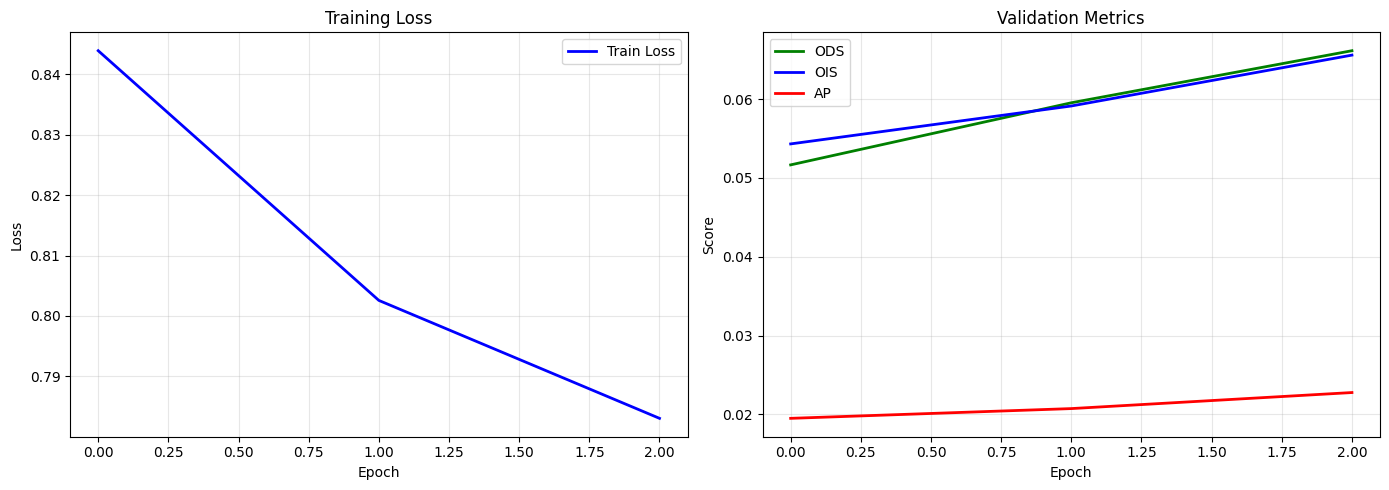

In [38]:
# Cell 7: Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], 'b-', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metrics
axes[1].plot(history['val_ods'], 'g-', linewidth=2, label='ODS')
axes[1].plot(history['val_ois'], 'b-', linewidth=2, label='OIS')
axes[1].plot(history['val_ap'], 'r-', linewidth=2, label='AP')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [41]:
# Cell 8: Final Test Evaluation

# Load best model
model.load_state_dict(torch.load('./models/best_xyw_net.pth'))
print("Loaded best model weights.\n")

# Evaluate on test set
print("Evaluating on TEST set...")
test_ods, test_ois, test_ap = evaluate(model, test_loader, device)

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"  ODS (Optimal Dataset Scale): {test_ods:.4f}")
print(f"  OIS (Optimal Image Scale):   {test_ois:.4f}")
print(f"  AP (Average Precision):      {test_ap:.4f}")
print("="*60)

C:\Users\imed\AppData\Local\Temp\ipykernel_20964\2695949868.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./models/best_xyw_net.pth')

Loaded best model weights.

Evaluating on TEST set...


Evaluating: 100%|██████████| 2/2 [00:02<00:00,  1.18s/it]



FINAL TEST RESULTS
  ODS (Optimal Dataset Scale): 0.0503
  OIS (Optimal Image Scale):   0.0506
  AP (Average Precision):      0.0165


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4110641].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


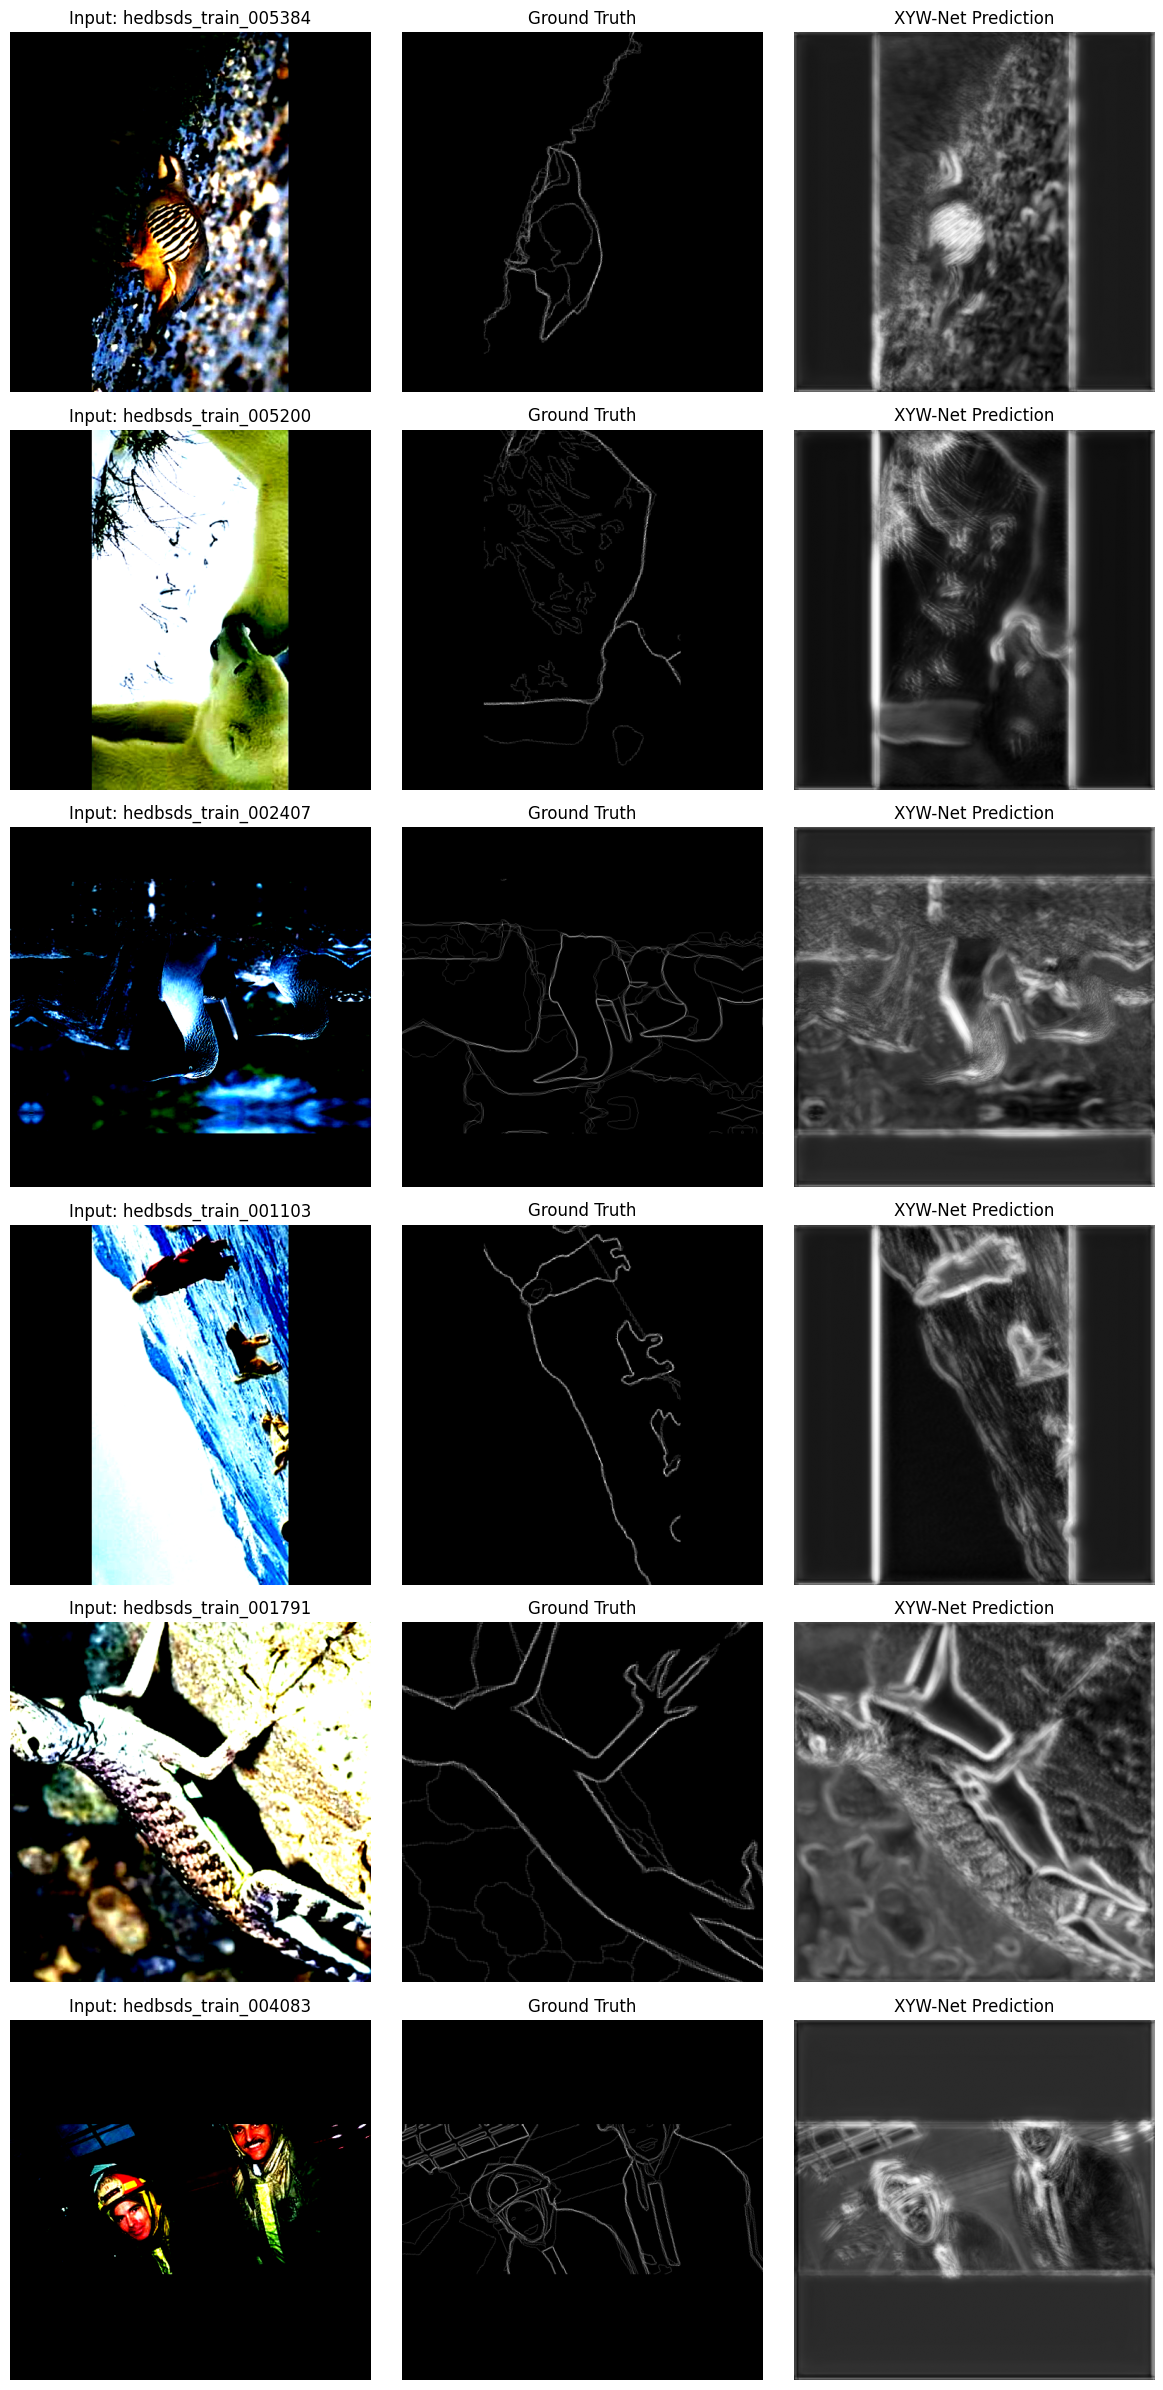

In [42]:
# Cell 9: Visualize Edge Predictions

@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=6):
    """Visualize predictions on random samples"""
    model.eval()
    
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        img = sample['images'].unsqueeze(0).to(device)
        label = sample['labels'][0].numpy()
        
        pred = model(img)[0, 0].cpu().numpy()
        
        # Original image
        axes[i, 0].imshow(sample['images'].permute(1, 2, 0).numpy())
        axes[i, 0].set_title(f'Input: {sample["filename"]}')
        axes[i, 0].axis('off')
        
        # Ground truth
        axes[i, 1].imshow(label, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Prediction
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title('XYW-Net Prediction')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=150)
    plt.show()

visualize_predictions(model, test_dataset, device, num_samples=6)

In [ ]:
# Cell 10: Visualize Encoder Stage Outputs

@torch.no_grad()
def visualize_stages(model, dataset, device, sample_idx=0):
    """Visualize feature maps at each encoder stage"""
    model.eval()
    
    sample = dataset[sample_idx]
    img = sample['images'].unsqueeze(0).to(device)
    
    # Get stage outputs
    final, (s1, s2, s3, s4) = model.forward_with_stages(img)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Original image
    axes[0, 0].imshow(sample['images'].permute(1, 2, 0).numpy())
    axes[0, 0].set_title('Input Image')
    axes[0, 0].axis('off')
    
    # Ground truth
    axes[0, 1].imshow(sample['labels'][0].numpy(), cmap='gray')
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')
    
    # Final prediction
    axes[0, 2].imshow(final[0, 0].cpu().numpy(), cmap='gray')
    axes[0, 2].set_title('Final Prediction')
    axes[0, 2].axis('off')
    
    # Thresholded prediction
    pred_binary = (final[0, 0].cpu().numpy() > 0.5).astype(float)
    axes[0, 3].imshow(pred_binary, cmap='gray')
    axes[0, 3].set_title('Prediction (threshold=0.5)')
    axes[0, 3].axis('off')
    
    # Stage feature maps (mean across channels)
    stages = [s1, s2, s3, s4]
    stage_names = ['Stage 1 (30ch)', 'Stage 2 (60ch)', 'Stage 3 (120ch)', 'Stage 4 (120ch)']
    
    for i, (stage, name) in enumerate(zip(stages, stage_names)):
        feat_mean = stage[0].mean(dim=0).cpu().numpy()
        feat_norm = (feat_mean - feat_mean.min()) / (feat_mean.max() - feat_mean.min() + 1e-8)
        axes[1, i].imshow(feat_norm, cmap='viridis')
        axes[1, i].set_title(f'{name}\nShape: {tuple(stage.shape[2:])}')
        axes[1, i].axis('off')
    
    plt.suptitle(f'XYW-Net Encoder Stage Outputs - {sample["filename"]}', fontsize=14)
    plt.tight_layout()
    plt.savefig('stage_outputs.png', dpi=150)
    plt.show()

# Visualize for a few samples
for idx in [0, 1, 2]:
    if idx < len(test_dataset):
        visualize_stages(model, test_dataset, device, sample_idx=idx)

AttributeError: 'XYWNet' object has no attribute 'forward_with_stages'

In [ ]:
# Cell 11: Precision-Recall Curve

@torch.no_grad()
def plot_pr_curve(model, loader, device):
    """Plot precision-recall curve"""
    model.eval()
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc='Computing PR curve'):
        images = batch['images'].to(device)
        labels = batch['labels']
        outputs = model(images)
        
        for i in range(outputs.shape[0]):
            all_preds.append(outputs[i, 0].cpu().numpy().flatten())
            all_labels.append((labels[i, 0].numpy().flatten() > 0.5).astype(int))
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    precision, recall, thresholds = precision_recall_curve(all_labels, all_preds)
    ap = average_precision_score(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, 'b-', linewidth=2, label=f'XYW-Net (AP={ap:.4f})')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve', fontsize=14)
    plt.legend(loc='lower left', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.savefig('pr_curve.png', dpi=150)
    plt.show()
    
    return ap

ap = plot_pr_curve(model, test_loader, device)
print(f"Average Precision: {ap:.4f}")

In [ ]:
# Cell 12: Summary Results Table

print("\n" + "="*70)
print("                    XYW-NET EVALUATION SUMMARY")
print("="*70)
print(f"")
print(f"  Dataset:          {DATA_ROOT}")
print(f"  Train samples:    {len(train_dataset)}")
print(f"  Val samples:      {len(val_dataset)}")
print(f"  Test samples:     {len(test_dataset)}")
print(f"")
print(f"  Training epochs:  {NUM_EPOCHS}")
print(f"  Learning rate:    {LEARNING_RATE}")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"")
print("  " + "-"*50)
print(f"  TEST SET METRICS:")
print("  " + "-"*50)
print(f"  ODS (Optimal Dataset Scale):   {test_ods:.4f}")
print(f"  OIS (Optimal Image Scale):     {test_ois:.4f}")
print(f"  AP (Average Precision):        {test_ap:.4f}")
print("="*70)
print(f"")
print("Saved files:")
print("  - best_xyw_net.pth      (model weights)")
print("  - training_history.png  (loss/metrics plot)")
print("  - predictions.png       (sample predictions)")
print("  - stage_outputs.png     (encoder stages)")
print("  - pr_curve.png          (precision-recall curve)")


- Changes made:
  - Added `nms_edge(pred)` and `dilate_gt(gt, r=1)` as a new utility cell at the top.
    - Use tolerance matching via `dilate_gt()` for ODS/OIS/AP.
    - Apply `cv2.GaussianBlur(pred, (3,3), 0)` to predictions before thresholding.
    - Set `thresholds = np.linspace(0.05, 0.95, 30)`.
  - Updated evaluation cell [e:\Edge Detection\xywnet_v2.1.ipynb](e:\Edge Detection\xywnet_v2.1.ipynb#L1039-L1080) to apply `nms_edge()` to predictions only before collecting for metrics.

- Ground truth policy:
  - GT is not modified in the dataset or training. Tolerance is applied only during evaluation matching.


Next steps:
- Confirm `opencv-contrib-python` is available for `cv2.ximgproc.thinning`. If missing, install:
```bash
pip install opencv-contrib-python
```
- Run the evaluation cell to verify ODS/OIS/AP and PR curves stabilize as expected. Want me to run the notebook cells in order and report the new metrics?

Made changes.